# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

## Domain
E-Commerce and Retail Analytics

## Problem Statement
The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. This project aims to analyze transaction data from an online retail business, segment customers using RFM (Recency, Frequency, Monetary) analysis, and develop a product recommendation system using item-based collaborative filtering techniques.

## Business Objectives
- Identify meaningful customer segments for targeted marketing.
- Detect at-risk customers for retention strategies.
- Recommend relevant products based on customer purchase patterns.
- Support inventory optimization and business decision-making.

## Machine Learning Approach
- Unsupervised Learning (Customer Segmentation)
- Collaborative Filtering (Product Recommendation System)

# Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

# Model Saving
import pickle

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [4]:
df = pd.read_csv('../data/online_retail.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
df.shape

(541909, 8)

### Observation

- The dataset contains **541,909 transaction records** and **8 features**.
- Each row represents a product purchased within a transaction.
- The dataset is large enough to perform customer behavior analysis and product recommendation modeling.
- The available features include transaction details, product information, customer identifiers, pricing information, and country details.
- This dataset is suitable for RFM-based customer segmentation and collaborative filtering recommendation systems.

### first five record

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Observation

- The dataset contains transaction-level retail sales information.
- Each row represents a product purchased within a specific invoice.
- `InvoiceNo` represents the transaction number.
- `StockCode` uniquely identifies each product.
- `Description` contains the product name.
- `Quantity` indicates the number of units purchased.
- `InvoiceDate` stores the transaction timestamp.
- `UnitPrice` represents the selling price per unit.
- `CustomerID` identifies the customer making the purchase.
- `Country` specifies the customer's country.
- Initial records show transactions from the United Kingdom, indicating that it may contribute significantly to overall sales.

In [7]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2023-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2023-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2023-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2023-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2023-12-09 12:50:00,4.95,12680.0,France


### Observation

- The final transactions in the dataset occurred on **09-Dec-2023**.
- The dataset covers approximately one year of retail transactions.
- Transactions are recorded at the product level, where a single invoice can contain multiple products.
- The last recorded customer belongs to **France**, indicating that the business serves international customers.
- Product purchases include children's products, kitchen items, and home accessories, suggesting a diverse product catalog.
- The dataset appears suitable for analyzing customer purchasing behavior across different countries and product categories.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Observation

- The dataset contains **541,909 records** and **8 columns**.
- There are **3 numerical features** (`Quantity`, `UnitPrice`, `CustomerID`) and **5 categorical features** (`InvoiceNo`, `StockCode`, `Description`, `InvoiceDate`, `Country`).
- The `InvoiceDate` column is currently stored as an **object datatype** and will need to be converted to datetime format for time-based analysis and RFM calculations.
- The `Description` column contains missing values.
- The `CustomerID` column contains a significant number of missing values.
- `InvoiceNo` and `StockCode` are stored as object data types, which is appropriate since they represent identifiers rather than numerical values.
- The dataset occupies approximately **33.1 MB** of memory.
- Before performing customer segmentation, missing customer records must be handled according to the project requirements.

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


### Dataset Summary

- The dataset contains 541,909 transaction records collected between December 2022 and December 2023.
- Customer purchase behavior can be analyzed using transaction-level and customer-level information.
- Missing values are present in both `Description` and `CustomerID`.
- The `InvoiceDate` column is currently stored as an object and will require datetime conversion.
- Negative values are present in both `Quantity` and `UnitPrice`, indicating cancelled transactions or invalid records.
- The maximum quantity purchased is 80,995 units, while the minimum quantity is -80,995 units, suggesting the presence of returns/cancellations.
- The dataset exhibits a highly skewed distribution in transaction quantities and prices, which is common in retail transaction data.

In [10]:
# Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# Duplicate Records
df.duplicated().sum()

np.int64(5268)

## Data Understanding Summary

The dataset contains 541,909 retail transaction records and 8 features. Analysis of the dataset revealed the following:

- The dataset contains missing values in `Description` (1,454 records) and `CustomerID` (135,080 records).
- There are 5,268 duplicate records present in the dataset.
- Negative values exist in both `Quantity` and `UnitPrice`, indicating returns, cancellations, or invalid transactions.
- The `InvoiceDate` column is stored as an object datatype and requires conversion to datetime format.
- Customer-level analysis is possible through the `CustomerID` field.
- The dataset spans approximately one year of transaction history and contains customers from multiple countries.

These findings indicate that data cleaning is required before performing exploratory analysis, customer segmentation, and recommendation modeling.

In [12]:
# Check cancelled invoices
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 8)

In [13]:
print("Missing CustomerID :", df['CustomerID'].isnull().sum())

print("Cancelled Invoices :", 
      df['InvoiceNo'].astype(str).str.startswith('C').sum())

print("Quantity <= 0 :", 
      (df['Quantity'] <= 0).sum())

print("UnitPrice <= 0 :", 
      (df['UnitPrice'] <= 0).sum())

print("Duplicate Records :", 
      df.duplicated().sum())

Missing CustomerID : 135080
Cancelled Invoices : 9288
Quantity <= 0 : 10624
UnitPrice <= 0 : 2517
Duplicate Records : 5268


# Data Cleaning

In [19]:
# Create a copy of the original dataset
df_clean = df.copy()

# Shape before cleaning
print("Shape Before Cleaning :", df_clean.shape)

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Remove missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean['InvoiceNo'].astype(str).str.startswith('C')
]

# Remove invalid quantities
df_clean = df_clean[df_clean['Quantity'] > 0]

# Remove invalid prices
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# Create Total Amount feature
df_clean['TotalAmount'] = (
    df_clean['Quantity'] * df_clean['UnitPrice']
)

# Shape after cleaning
print("Shape After Cleaning :", df_clean.shape)

Shape Before Cleaning : (541909, 8)
Shape After Cleaning : (397884, 9)


## Data Cleaning Summary

Data cleaning was performed according to the project requirements to ensure data quality and consistency.

The following preprocessing steps were applied:

- Converted `InvoiceDate` to datetime format.
- Removed records with missing `CustomerID`.
- Excluded cancelled invoices identified by invoice numbers starting with 'C'.
- Removed transactions with non-positive quantities.
- Removed transactions with non-positive unit prices.
- Created a new feature `TotalAmount` representing the transaction value.

### Dataset Size After Cleaning

| Metric | Count |
|----------|----------:|
| Original Records | 541,909 |
| Cleaned Records | 397,884 |
| Records Removed | 144,025 |

The cleaned dataset is now ready for exploratory data analysis, customer segmentation, and recommendation modeling.

In [15]:
print(df_clean.isnull().sum())

print("\nQuantity <= 0 :", (df_clean['Quantity'] <= 0).sum())

print("UnitPrice <= 0 :", (df_clean['UnitPrice'] <= 0).sum())

print(
    "Cancelled Invoices :",
    df_clean['InvoiceNo'].astype(str).str.startswith('C').sum()
)

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Quantity <= 0 : 0
UnitPrice <= 0 : 0
Cancelled Invoices : 0


In [17]:
print("Original Dataset Shape :", df.shape)
print("Cleaned Dataset Shape :", df_clean.shape)

Original Dataset Shape : (541909, 8)
Cleaned Dataset Shape : (397884, 9)


# EDA-1: Transaction Volume by Country

In [20]:
country_transactions = (
    df_clean.groupby('Country')['InvoiceNo']
    .count()
    .sort_values(ascending=False)
)

country_transactions.head(10)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: InvoiceNo, dtype: int64

### Transaction Volume by Country

- The United Kingdom dominates transaction activity with 354,321 transactions, accounting for the vast majority of sales.
- Germany, France, and EIRE are the next most active markets but contribute significantly less volume than the UK.
- The business has an international customer base, with transactions recorded across multiple European countries and Australia.
- The distribution is highly imbalanced, indicating that customer behavior is primarily driven by the UK market.

# Visualization

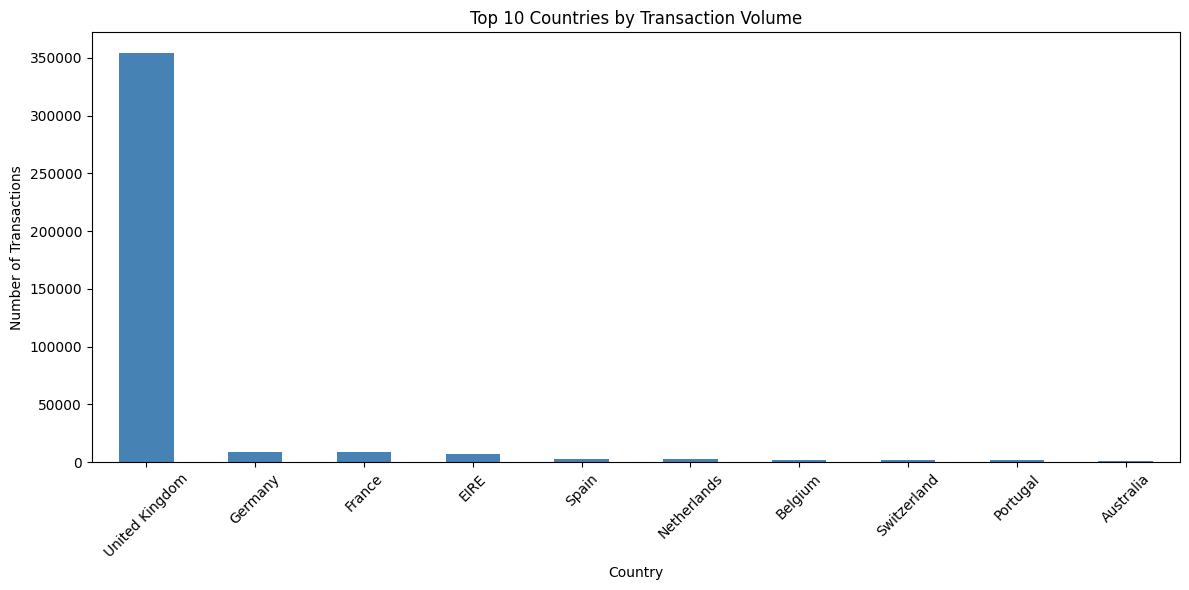

In [21]:
plt.figure(figsize=(12,6))

country_transactions.head(10).plot(
    kind='bar',
    color='steelblue'
)

plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Top Selling Products

In [22]:
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

### Top Selling Products

- Home décor, gift items, and household accessories dominate product sales.
- `PAPER CRAFT, LITTLE BIRDIE` recorded the highest sales quantity.
- Products such as `WHITE HANGING HEART T-LIGHT HOLDER` and `JUMBO BAG RED RETROSPOT` are among the most frequently purchased items.
- The top-selling products indicate strong customer preference for decorative and gift-oriented merchandise.

# Visualization

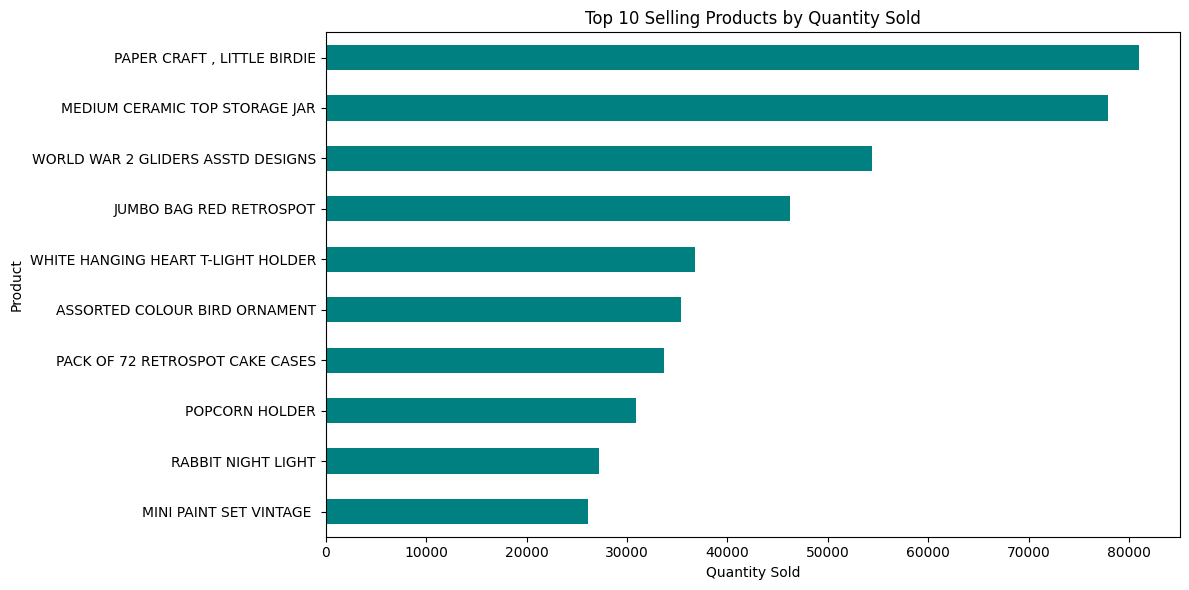

In [23]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(
    kind='barh',
    color='teal'
)

plt.title('Top 10 Selling Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

# Purchase Trend Over Time

## monthly sales trend: 

In [24]:
monthly_transactions = (
    df_clean
    .set_index('InvoiceDate')
    .resample('M')['InvoiceNo']
    .count()
)

monthly_transactions

InvoiceDate
2022-12-31    26157
2023-01-31    21229
2023-02-28    19927
2023-03-31    27175
2023-04-30    22642
2023-05-31    28320
2023-06-30    27185
2023-07-31    26825
2023-08-31    27007
2023-09-30    40028
2023-10-31    49554
2023-11-30    64531
2023-12-31    17304
Freq: ME, Name: InvoiceNo, dtype: int64

### Purchase Trend Over Time

- Transaction volume remains relatively stable between January and August.
- A significant increase is observed from September onwards.
- October and November show the highest transaction activity.
- November recorded the peak transaction volume with 64,531 transactions.
- The surge in Q4 suggests strong seasonal demand, likely influenced by holiday shopping and year-end sales events.
- December appears lower because the dataset ends on 09-Dec-2023 and does not contain the full month's transactions.

# Visualization

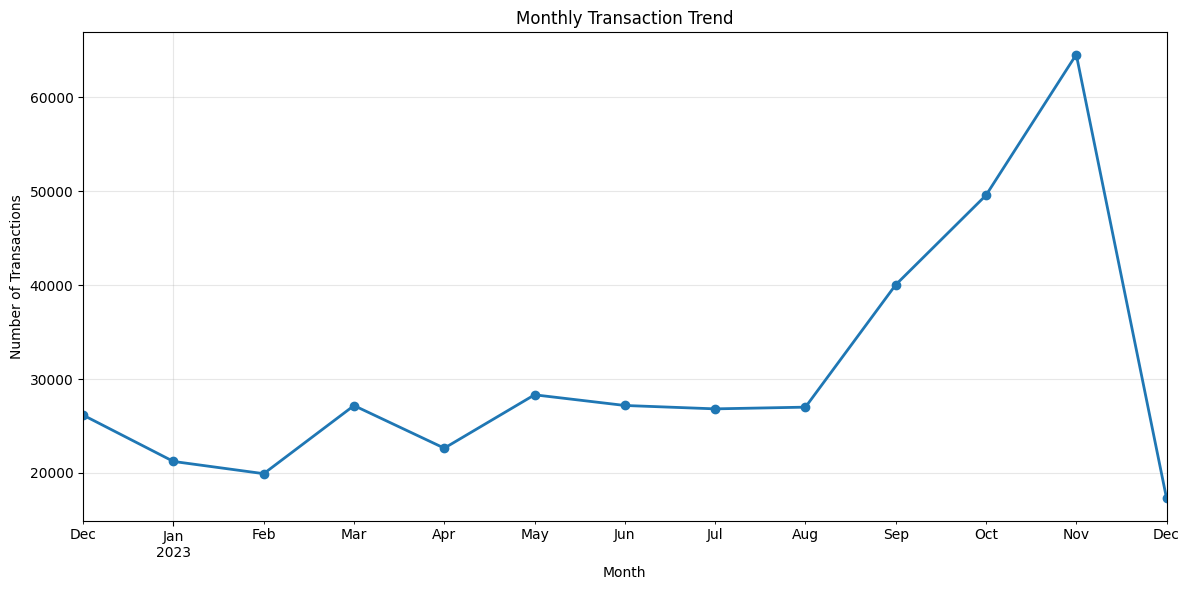

In [26]:
plt.figure(figsize=(12,6))

monthly_transactions.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Transaction Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Inspect monetary distribution per transaction and customer

### Transaction Value Distribution first:

In [27]:
df_clean['TotalAmount'].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

### Monetary Distribution per Transaction

- The average transaction value is £22.40.
- The median transaction value is £11.80, which is significantly lower than the mean.
- This indicates a highly right-skewed distribution where a small number of large purchases increase the average transaction value.
- The maximum transaction value (£168,469.60) is substantially higher than typical purchases, suggesting the presence of extreme outliers.
- Most transactions fall below £20, indicating that customer purchases are generally small to medium-sized.

# Visualization

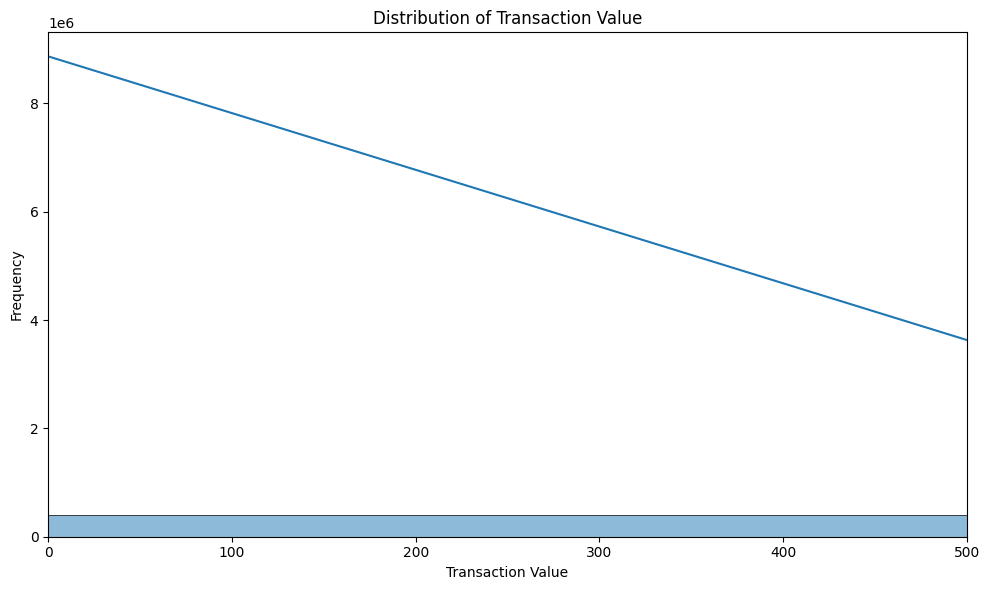

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean['TotalAmount'],
    bins=100,
    kde=True
)

plt.title('Distribution of Transaction Value')
plt.xlabel('Transaction Value')
plt.ylabel('Frequency')

plt.xlim(0, 500)

plt.tight_layout()
plt.show()

# Inspect monetary distribution per customer

## transaction-level to customer-level spending: 

In [29]:
customer_spend = (
    df_clean.groupby('CustomerID')['TotalAmount']
    .sum()
)

customer_spend.describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalAmount, dtype: float64

### Monetary Distribution per Customer

- The dataset contains 4,338 unique customers after cleaning.
- The average customer spending is £2,054.27.
- The median customer spending is £674.49, which is considerably lower than the average.
- This indicates that a relatively small group of customers contributes a large portion of total revenue.
- Customer spending is highly skewed, with the highest-spending customer contributing over £280,000.
- The business appears to follow a Pareto-like pattern, where a minority of customers generate a significant share of revenue.

# Visualization

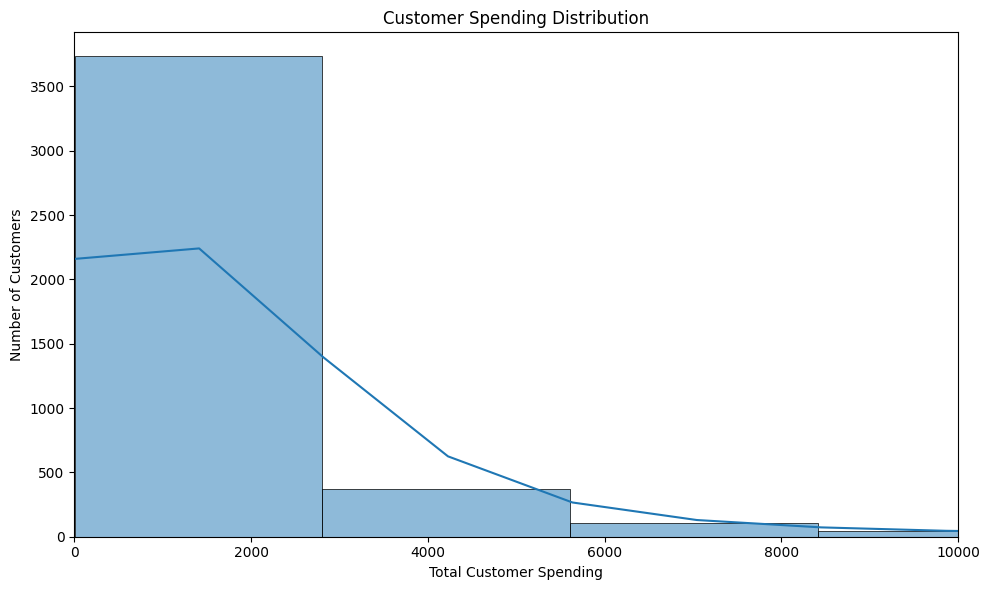

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    customer_spend,
    bins=100,
    kde=True
)

plt.title('Customer Spending Distribution')
plt.xlabel('Total Customer Spending')
plt.ylabel('Number of Customers')

plt.xlim(0, 10000)

plt.tight_layout()
plt.show()

# RFM Analysis

## Step 1: Create RFM Table

In [31]:
# Snapshot date (1 day after last transaction)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Table
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [33]:
rfm.shape

(4338, 3)

## RFM Feature Engineering

RFM (Recency, Frequency, Monetary) analysis was performed to quantify customer purchasing behavior.

- Recency: Number of days since the customer's most recent purchase.
- Frequency: Number of unique transactions made by the customer.
- Monetary: Total amount spent by the customer.

The resulting RFM dataset contains 4,338 customers and serves as the foundation for customer segmentation.

In [34]:
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


# Visualization

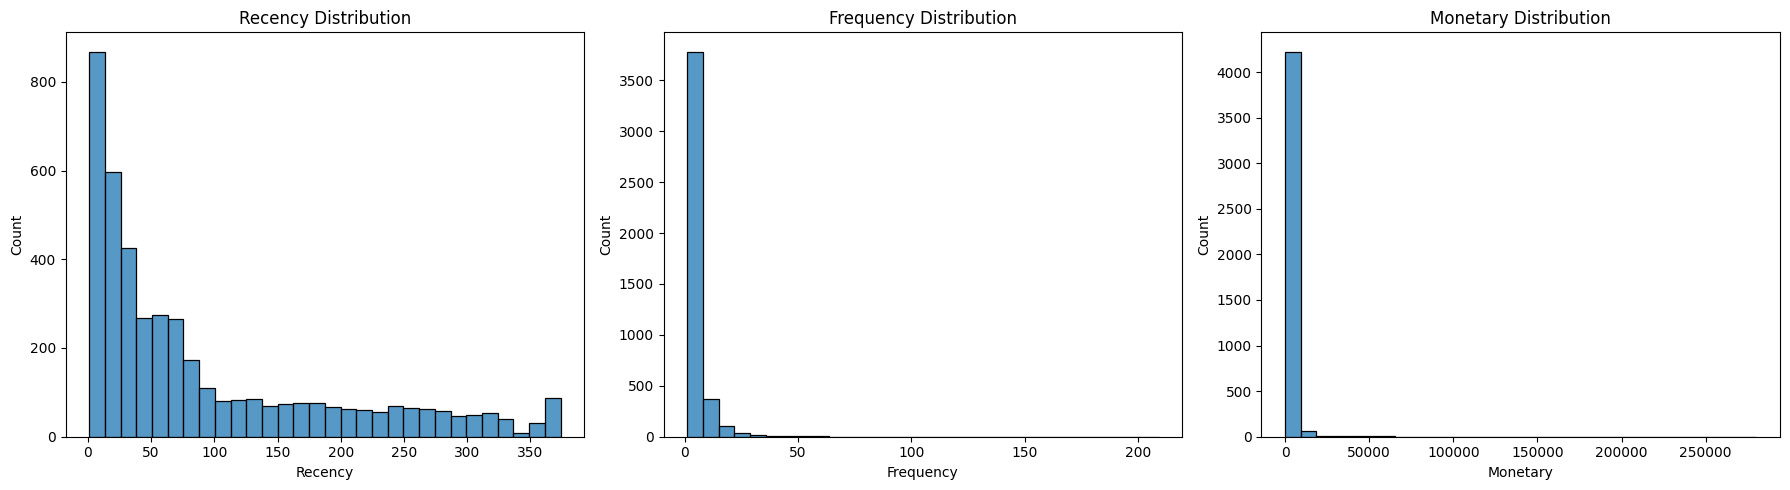

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

### RFM Distribution Analysis

- Recency shows a moderate right-skewed distribution, indicating that many customers purchased recently while a smaller group has been inactive for longer periods.
- Frequency is highly right-skewed, with most customers making only a few purchases and a small number of customers purchasing very frequently.
- Monetary value is extremely right-skewed, where a majority of customers contribute relatively low spending while a few customers generate exceptionally high revenue.
- The presence of strong skewness and outliers suggests that transformation and scaling are necessary before applying K-Means clustering.

# Log Transformation

In [38]:
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


# Scaling

In [39]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled.shape

(4338, 3)

## Verify Transformation

In [40]:
rfm_log.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,3.830734,1.340261,0.693147,2.944439,3.951244,4.962845,5.926926
Frequency,4338.0,1.345582,0.683104,0.693147,0.693147,1.098612,1.791759,5.347108
Monetary,4338.0,6.593627,1.257578,1.558145,5.731446,6.515431,7.416222,12.543284


# Elbow Method

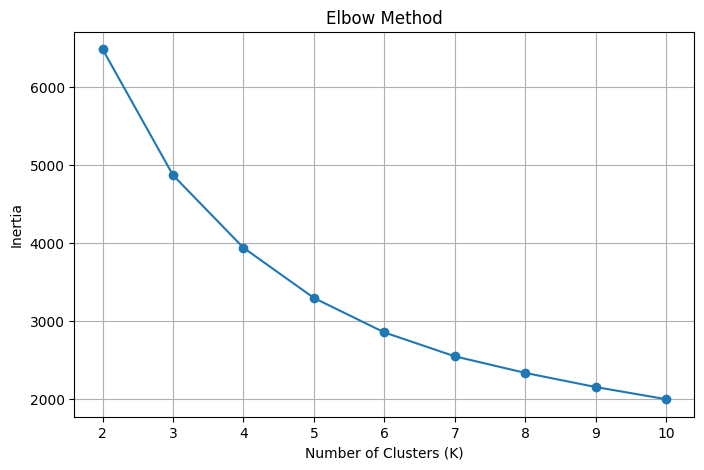

In [41]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.grid(True)
plt.show()

# Silhouette Score

In [42]:
silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    'K': list(K),
    'Silhouette Score': silhouette_scores
})

silhouette_df

,K,Silhouette Score
0,2,0.432940
1,3,0.336510
2,4,0.337134
3,5,0.316097
4,6,0.313329
5,7,0.309975
6,8,0.300782
7,9,0.281653
8,10,0.278665


## Cluster Selection

Two methods were used to determine the optimal number of customer segments:

### Elbow Method
The elbow curve showed a noticeable bend around K=4, indicating diminishing returns in inertia reduction beyond this point.

### Silhouette Score
Although K=2 achieved the highest silhouette score, it would produce only two broad customer groups and would not provide sufficient business granularity.

### Final Cluster Selection
Based on the Elbow Method, Silhouette Analysis, and business requirements, K=4 was selected as the optimal number of customer segments.

This allows meaningful interpretation of customers as:
- High-Value Customers
- Regular Customers
- Occasional Customers
- At-Risk Customers

# Train Final KMeans Model

In [43]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,2
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,3


# Cluster Sizes

In [44]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

# Cluster Interpretation

In [45]:
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,18.12,2.15,551.82
1,12.13,13.71,8074.27
2,71.08,4.08,1802.83
3,182.50,1.32,343.45


# Create Segment Labels

In [46]:
segment_mapping = {
    0: 'Occasional',
    1: 'High-Value',
    2: 'Regular',
    3: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_mapping)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,2,Regular
12347.0,2,7,4310.00,1,High-Value
12348.0,75,4,1797.24,2,Regular
12349.0,19,1,1757.55,0,Occasional
12350.0,310,1,334.40,3,At-Risk


# Segment Distribution

In [47]:
rfm['Segment'].value_counts()

Segment
At-Risk       1612
Regular       1173
Occasional     837
High-Value     716
Name: count, dtype: int64

# Cluster Summary Table (Profile Table)

In [48]:
segment_profile = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At-Risk,182.50,1.32,343.45
High-Value,12.13,13.71,8074.27
Occasional,18.12,2.15,551.82
Regular,71.08,4.08,1802.83


# Cluster Visualization

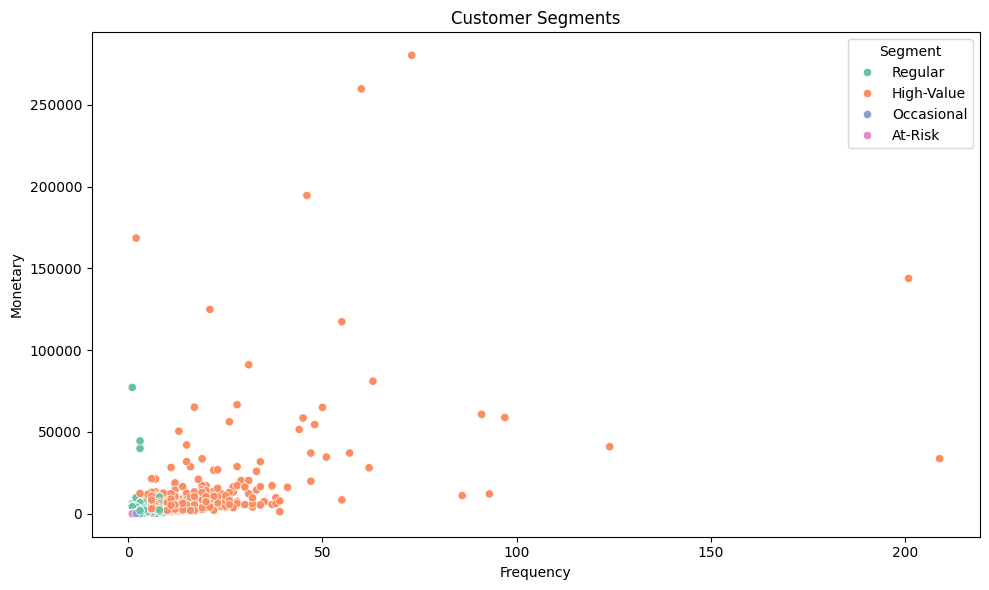

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='Set2'
)

plt.title('Customer Segments')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.tight_layout()
plt.show()

In [50]:
df_clean['Description'].nunique()

3877

# Product Recommendation System

## Step 1: Product-Customer Matrix

In [51]:
product_customer_matrix = pd.pivot_table(
    df_clean,
    index='Description',
    columns='CustomerID',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

product_customer_matrix.shape

(3877, 4338)

# Step 2: Product Similarity Matrix

In [52]:
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    product_customer_matrix
)

product_similarity.shape

(3877, 3877)

# Step 3: Similarity DataFrame

In [53]:
similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

similarity_df.shape

(3877, 3877)

# Step 4: Recommendation Function

In [54]:
def recommend_products(product_name, n_recommendations=5):

    if product_name not in similarity_df.index:
        return ["Product not found"]

    similar_scores = similarity_df[product_name].sort_values(
        ascending=False
    )

    recommendations = similar_scores.iloc[
        1:n_recommendations+1
    ].index.tolist()

    return recommendations

# Step 5: Test Recommendation

In [55]:
recommend_products(
    'WHITE HANGING HEART T-LIGHT HOLDER'
)

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

In [56]:
recommend_products(
    'GREEN VINTAGE SPOT BEAKER'
)

['BLUE VINTAGE SPOT BEAKER',
 'PINK VINTAGE SPOT BEAKER',
 'POTTING SHED CANDLE CITRONELLA',
 'POTTING SHED ROSE CANDLE',
 'PANTRY CHOPPING BOARD']

# Product recommendation heatmap / similarity matrix

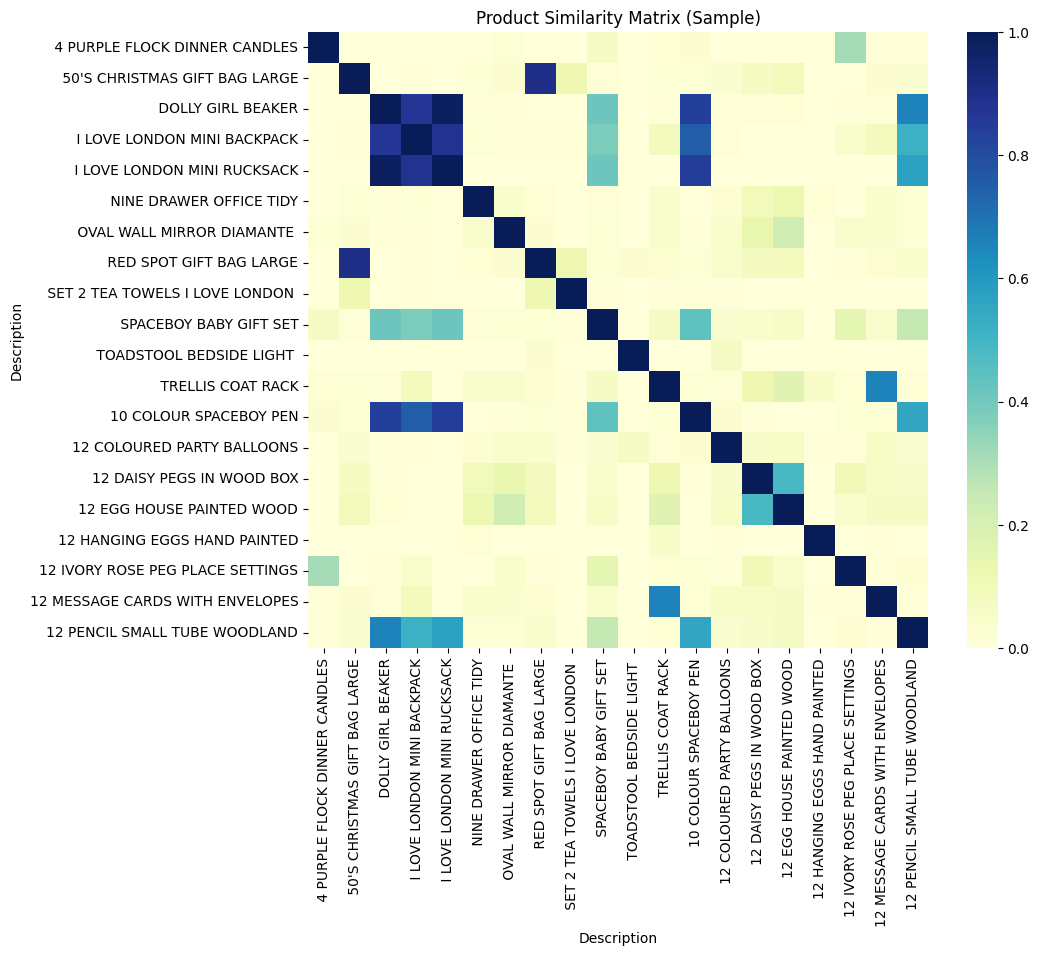

In [63]:
plt.figure(figsize=(10,8))

sample_products = similarity_df.iloc[:20, :20]

sns.heatmap(
    sample_products,
    cmap='YlGnBu'
)

plt.title('Product Similarity Matrix (Sample)')
plt.show()

### Product Similarity Analysis

- The heatmap visualizes similarity scores between products.
- Higher values indicate products frequently purchased by similar customer groups.
- This similarity matrix forms the foundation of the item-based recommendation engine.

# Save Artifacts

In [57]:
import pickle

pickle.dump(
    similarity_df,
    open('../models/product_similarity.pkl', 'wb')
)

pickle.dump(
    list(product_customer_matrix.index),
    open('../models/product_list.pkl', 'wb')
)

print("Recommendation artifacts saved successfully")

Recommendation artifacts saved successfully


In [61]:
feature_columns = ['Recency', 'Frequency', 'Monetary']

pickle.dump(
    feature_columns,
    open('../models/feature_columns.pkl', 'wb')
)

print("Feature columns saved successfully")

Feature columns saved successfully


# Save Segmentation Artifacts (MODEL)

In [58]:
pickle.dump(kmeans, open('../models/kmeans.pkl', 'wb'))
pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))
pickle.dump(segment_mapping, open('../models/segment_mapping.pkl', 'wb'))

print("Segmentation artifacts saved successfully")

Segmentation artifacts saved successfully


# Deployment Preparation

The following artifacts are saved for Streamlit deployment:

- kmeans.pkl
- scaler.pkl
- segment_mapping.pkl
- product_similarity.pkl
- product_list.pkl
- feature_columns.pkl

These files will be used for customer segmentation prediction and product recommendation within the Streamlit application.

# Check models exist or not

In [64]:
import os
os.listdir('../models')

['feature_columns.pkl',
 'kmeans.pkl',
 'product_list.pkl',
 'product_similarity.pkl',
 'scaler.pkl',
 'segment_mapping.pkl']

### Future Improvements:
- Deploy application on Streamlit Cloud
- Use hybrid recommendation systems
- Add real-time customer analytics dashboard

# Conclusion

### Customer Segmentation

- High-Value customers contribute the highest revenue and purchase most frequently.
- Regular customers generate consistent business value.
- Occasional customers present opportunities for targeted marketing campaigns.
- At-Risk customers require retention strategies to improve engagement.

### Product Recommendation System

- Item-based collaborative filtering successfully identified similar products based on customer purchase behavior.
- The recommendation engine generated meaningful product suggestions aligned with business expectations.
- The developed system can support personalized shopping experiences and improve customer engagement.

### Business Impact

- Improved customer targeting
- Better retention planning
- Enhanced cross-selling opportunities
- Data-driven marketing decisions